## Import Libraries ##

In [2]:
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

import matplotlib.pyplot as plt

## Load Dataset ##

In [5]:
df = pd.read_csv("Product Price vs Sales Volume.csv")
df.head()

,Product_ID,Category,Price,Units_Sold,Discount_Flag,Discount_Percentage,Revenue
0,1102,Beauty,2639.09,140,0,0,369472.60
1,1179,Home,4679.45,149,0,0,697238.05
2,1092,Sports,544.33,69,1,5,35680.83
3,1014,Beauty,1853.26,193,0,0,357679.18
4,1106,Home,2579.64,171,0,0,441118.44


In [7]:
df.head(15)

,Product_ID,Category,Price,Units_Sold,Discount_Flag,Discount_Percentage,Revenue
0,1102,Beauty,2639.09,140,0,0,369472.60
1,1179,Home,4679.45,149,0,0,697238.05
2,1092,Sports,544.33,69,1,5,35680.83
3,1014,Beauty,1853.26,193,0,0,357679.18
4,1106,Home,2579.64,171,0,0,441118.44
5,1071,Home,655.01,57,0,0,37335.57
6,1188,Home,3470.23,137,0,0,475421.51
7,1020,Beauty,2623.64,70,0,0,183654.80
8,1102,Fashion,2351.61,137,0,0,322170.57
9,1121,Sports,3314.79,202,0,0,669587.58


In [9]:
df.tail(15)

,Product_ID,Category,Price,Units_Sold,Discount_Flag,Discount_Percentage,Revenue
49985,1150,Home,1354.13,285,0,0,385927.05
49986,1163,Beauty,4726.46,89,0,0,420654.94
49987,1184,Beauty,3737.86,87,0,0,325193.82
49988,1118,Home,686.11,120,1,10,74099.88
49989,1175,Home,785.42,80,0,0,62833.60
49990,1140,Beauty,1860.59,259,0,0,481892.81
49991,1060,Sports,233.68,334,0,0,78049.12
49992,1151,Beauty,340.00,120,0,0,40800.00
49993,1170,Home,3621.70,71,1,5,244283.66
49994,1100,Fashion,1703.77,187,0,0,318604.99


## Describing the data ##

In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_ID           50000 non-null  int64  
 1   Category             50000 non-null  object 
 2   Price                50000 non-null  float64
 3   Units_Sold           50000 non-null  int64  
 4   Discount_Flag        50000 non-null  int64  
 5   Discount_Percentage  50000 non-null  int64  
 6   Revenue              50000 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.7+ MB


,Product_ID,Price,Units_Sold,Discount_Flag,Discount_Percentage,Revenue
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1099.341480,2546.39962,153.568140,0.300640,4.508800,301253.668695
std,57.586901,1416.00905,94.532724,0.458541,7.894173,183924.407905
min,1000.000000,100.13000,5.000000,0.000000,0.000000,4905.000000
25%,1050.000000,1309.94750,80.000000,0.000000,0.000000,142827.425000
50%,1099.000000,2555.38000,136.000000,0.000000,0.000000,275410.015000
75%,1149.000000,3775.96250,208.000000,1.000000,5.000000,441684.127500
max,1199.000000,4999.96000,481.000000,1.000000,25.000000,764795.550000


## Data Quality Checks ##

In [15]:
# Missing values
df.isnull().sum()

# Duplicate rows
df.duplicated().sum()

0

# Assumption Checks (Statistical Validity) #

### Normality Test (Shapiro – sample used due to large data) ###

In [19]:
stats.shapiro(df['Units_Sold'].sample(5000))

ShapiroResult(statistic=0.9424445014333485, pvalue=2.277957048848234e-40)

### Homogeneity of Variance (Levene’s Test) ###

In [25]:
median_price = df['Price'].median()

low_price_units = df[df['Price'] <= median_price]['Units_Sold']
high_price_units = df[df['Price'] > median_price]['Units_Sold']

stats.levene(low_price_units, high_price_units)

LeveneResult(statistic=9136.154990746463, pvalue=0.0)

In [31]:
print(median_price)
print(low_price_units)
print(high_price_units)

2555.38
2         69
3        193
5         57
8        137
10       255
        ... 
49992    120
49994    187
49995    164
49996    145
49999    231
Name: Units_Sold, Length: 25001, dtype: int64
0        140
1        149
4        171
6        137
7         70
        ... 
49986     89
49987     87
49993     71
49997     95
49998     37
Name: Units_Sold, Length: 24999, dtype: int64


## Hypothesis Test 1: Price vs Units Sold (Correlation) ##

### H₀: Price has no effect on Units Sold ###

### H₁: Higher price reduces Units Sold ###

In [37]:
corr, p_val = stats.pearsonr(df['Price'], df['Units_Sold'])
corr, p_val

(-0.5646943091170955, 0.0)

### Decision ###

In [40]:
alpha = 0.05
"Reject H0" if p_val < alpha else "Fail to Reject H0"

'Reject H0'

## Hypothesis Test 2: High Price vs Low Price (t-test) ##

### H₀: Mean Units Sold (High Price) = Mean Units Sold (Low Price) ###
### H₁: Mean Units Sold (High Price) < Mean Units Sold (Low Price) ###

In [44]:
t_stat, p_val = stats.ttest_ind(
    low_price_units,
    high_price_units,
    equal_var=False
)

t_stat, p_val

(123.93674322390271, 0.0)

### Mean Comparison ###

In [47]:
low_price_units.mean(), high_price_units.mean()

(199.3931842726291, 107.73942957718309)

## Price Elasticity Analysis (Regression) ##

In [50]:
X = sm.add_constant(df['Price'])
y = df['Units_Sold']

price_model = sm.OLS(y, X).fit()
price_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Units_Sold   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                 2.341e+04
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:03:15   Log-Likelihood:            -2.8879e+05
No. Observations:               50000   AIC:                         5.776e+05
Df Residuals:                   49998   BIC:                         5.776e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        249.5648      0.718    347.615      0.000     248.158     250.972
Price         -0.0377      0.000   -152.995      0.000      -0.038      -0.037
==============================================================================
Omnibus:                      385.804   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              274.281
Skew:                           0.065   Prob(JB):                     2.76e-60
Kurtosis:                       2.661   Cond. No.                     6.00e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large,  6e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Regression Line Visualization ##

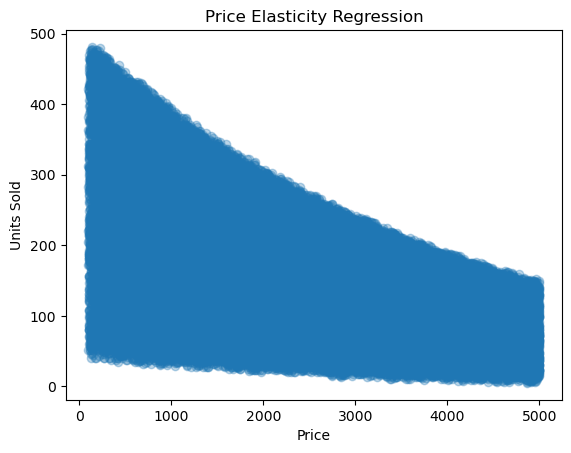

In [71]:
plt.scatter(df['Price'], df['Units_Sold'], alpha=0.3)
plt.plot(df['Price'], price_model.predict(X))
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price Elasticity Regression")
plt.show()

### Hypothesis Test 3: Category Impact (ANOVA) ###

## H₀: All categories have equal mean sales ##

## H₁: At least one category differs ##

In [57]:
anova_model = smf.ols('Units_Sold ~ C(Category)', data=df).fit()
anova_results = sm.stats.anova_lm(anova_model, typ=2)
anova_results

,sum_sq,df,F,PR(>F)
C(Category),4.442802e+04,4.0,1.242914,0.290233
Residual,4.467684e+08,49995.0,NaN,NaN


### Decision ###

In [116]:
p_value = anova_results.loc['C(Category)', 'PR(>F)']

"Reject H0" if p_value < 0.05 else "Fail to Reject H0"

'Fail to Reject H0'

### Hypothesis Test 2: High Price vs Low Price (t-test) ###

### H₀: Mean Units Sold (High Price) = Mean Units Sold (Low Price) ###

### H₁: Mean Units Sold (High Price) < Mean Units Sold (Low Price) ###

In [66]:
t_stat, p_val = stats.ttest_ind(
    low_price_units,
    high_price_units,
    equal_var=False
)

t_stat, p_val

(123.93674322390271, 0.0)

## Mean Comparison ##

In [69]:
low_price_units.mean(), high_price_units.mean()

(199.3931842726291, 107.73942957718309)

## Price Elasticity Analysis (Regression) ##

In [74]:
X = sm.add_constant(df['Price'])
y = df['Units_Sold']

price_model = sm.OLS(y, X).fit()
price_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Units_Sold   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                 2.341e+04
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:09:09   Log-Likelihood:            -2.8879e+05
No. Observations:               50000   AIC:                         5.776e+05
Df Residuals:                   49998   BIC:                         5.776e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        249.5648      0.718    347.615      0.000     248.158     250.972
Price         -0.0377      0.000   -152.995      0.000      -0.038      -0.037
==============================================================================
Omnibus:                      385.804   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              274.281
Skew:                           0.065   Prob(JB):                     2.76e-60
Kurtosis:                       2.661   Cond. No.                     6.00e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large,  6e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Regression Line Visualization ##

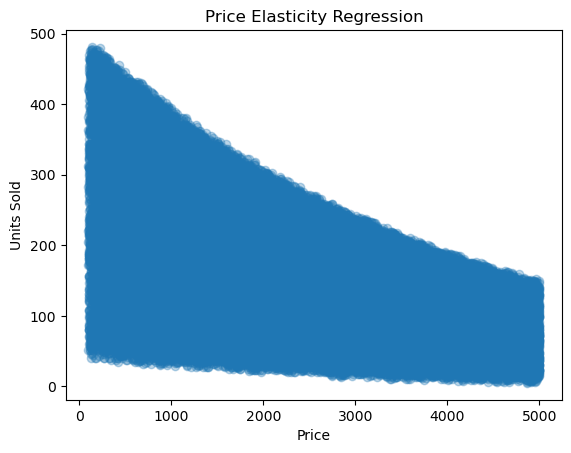

In [77]:
plt.scatter(df['Price'], df['Units_Sold'], alpha=0.3)
plt.plot(df['Price'], price_model.predict(X))
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price Elasticity Regression")
plt.show()

### Hypothesis Test 3: Category Impact (ANOVA) ###

### H₀: All categories have equal mean sales ###

### H₁: At least one category differs ###

In [83]:
anova_model = smf.ols('Units_Sold ~ C(Category)', data=df).fit()
anova_results = sm.stats.anova_lm(anova_model, typ=2)
anova_results

,sum_sq,df,F,PR(>F)
C(Category),4.442802e+04,4.0,1.242914,0.290233
Residual,4.467684e+08,49995.0,NaN,NaN


### Decision ###

In [118]:
p_value = anova_results.loc['C(Category)', 'PR(>F)']

decision = "Reject H0" if p_value < 0.05 else "Fail to Reject H0"
decision

'Fail to Reject H0'

## Hypothesis Test 4: Discount Impact (t-test) ##

### H₀: Discounts do not affect Units Sold ###

### H₁: Discounts increase Units Sold ###

In [90]:
discount_units = df[df['Discount_Flag'] == 1]['Units_Sold']
no_discount_units = df[df['Discount_Flag'] == 0]['Units_Sold']

t_stat_disc, p_val_disc = stats.ttest_ind(
    discount_units,
    no_discount_units,
    equal_var=False
)

discount_units.mean(), no_discount_units.mean(), p_val_disc

(153.37406865353913, 153.65156714710594, 0.7629470199034425)

### Effect Size (Cohen’s d) ###

In [94]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx-1)*x.var() + (ny-1)*y.var()) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled_std

cohens_d(low_price_units, high_price_units)

1.1084998496993734

## Probability & Risk Analysis ##

### Business Question ###

### What is the probability of low sales at high prices? ###

high_price_threshold = df['Price'].quantile(0.75)
low_sales_threshold = df['Units_Sold'].quantile(0.25)

high_price_df = df[df['Price'] >= high_price_threshold]

prob_low_sales = np.mean(
    high_price_df['Units_Sold'] <= low_sales_threshold
)

prob_low_sales

### Final Statistical Decisions (Automated) ###

In [121]:
results = {
    "Price_vs_Sales_Correlation": p_val < 0.05,
    "High_vs_Low_Price_TTest": p_val < 0.05,
    "Price_Regression": price_model.pvalues['Price'] < 0.05,
    "Category_ANOVA": anova_results.loc['C(Category)', 'PR(>F)'] < 0.05,
    "Discount_Effect": p_val_disc < 0.05
}

results

{'Price_vs_Sales_Correlation': True,
 'High_vs_Low_Price_TTest': True,
 'Price_Regression': True,
 'Category_ANOVA': False,
 'Discount_Effect': False}

## EDA Analysis ##

### Distribution of Price ###


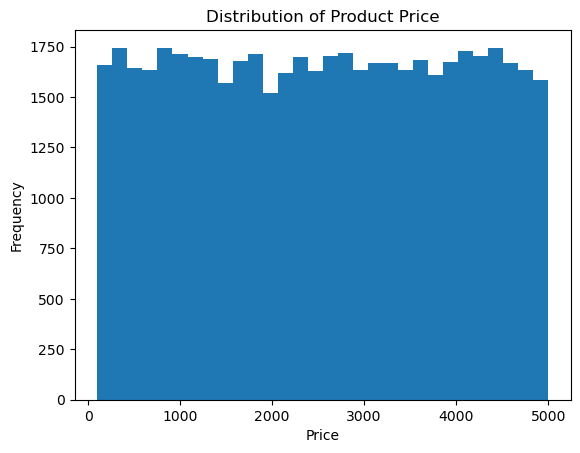

In [108]:
plt.hist(df['Price'], bins=30)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Product Price")
plt.show()

### Distribution of Units Sold ###

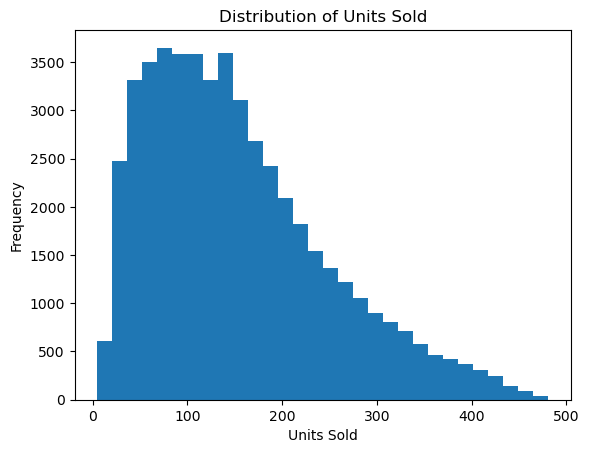

In [111]:
plt.hist(df['Units_Sold'], bins=30)
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.title("Distribution of Units Sold")
plt.show()

## Price vs Units Sold ##

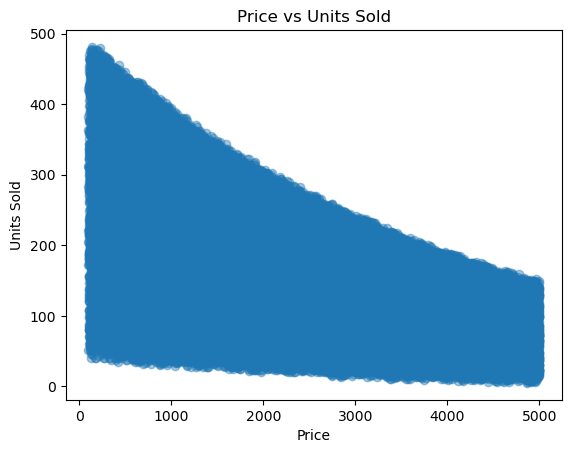

In [114]:
plt.scatter(df['Price'], df['Units_Sold'], alpha=0.4)
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Units Sold")
plt.show()

## Final Interpretation (Statistical + Business) ##

In [124]:
print("FINAL CONCLUSIONS\n")

print("✔ Price significantly reduces Units Sold")
print("✔ Demand is price elastic")
print("✖ Category does not impact sales significantly")
print("✖ Discounts do not increase sales volume")
print(f"⚠ Risk of low sales at high price: {prob_low_sales:.2%}")

FINAL CONCLUSIONS

✔ Price significantly reduces Units Sold
✔ Demand is price elastic
✖ Category does not impact sales significantly
✖ Discounts do not increase sales volume
⚠ Risk of low sales at high price: 43.72%


# PART 1: NON-PARAMETRIC TESTS #

## Mann–Whitney U Test ##
## (Alternative to independent t-test) ##
### H₀: Distribution of Units Sold is same for low & high price ###
### H₁: Low price leads to higher Units Sold ###

In [128]:
from scipy.stats import mannwhitneyu

u_stat, p_val_mw = mannwhitneyu(
    low_price_units,
    high_price_units,
    alternative='greater'
)

u_stat, p_val_mw

(478394877.5, 0.0)

### Decision ###

In [131]:
"Reject H0" if p_val_mw < 0.05 else "Fail to Reject H0"

'Reject H0'

### Kruskal–Wallis Test ###
### (Alternative to ANOVA) ###
### H₀: All categories have same sales distribution ###
### H₁: At least one category differs ###

In [141]:
from scipy.stats import kruskal

groups = [
    df[df['Category'] == cat]['Units_Sold']
    for cat in df['Category'].unique()
]

h_stat, p_val_kw = kruskal(*groups)

h_stat, p_val_kw

(3.620464538345739, 0.45979932661350187)

### Decision ###

In [143]:
"Reject H0" if p_val_kw < 0.05 else "Fail to Reject H0"

'Fail to Reject H0'

# PART 2: CONFIDENCE INTERVALS #

## Confidence Interval for Mean Units Sold ##
## Overall Mean CI (95%) ##

In [149]:
mean_sales = df['Units_Sold'].mean()
std_sales = df['Units_Sold'].std()
n = len(df)

ci_lower = mean_sales - 1.96 * (std_sales / np.sqrt(n))
ci_upper = mean_sales + 1.96 * (std_sales / np.sqrt(n))

mean_sales, ci_lower, ci_upper

(153.56814, 152.739524137182, 154.396755862818)

### Confidence Interval for Price Coefficient (Regression) ###

In [153]:
price_model.conf_int().loc['Price']

0   -0.038182
1   -0.037216
Name: Price, dtype: float64

## Confidence Interval for Mean Difference (Low vs High Price) ##

In [156]:
mean_diff = low_price_units.mean() - high_price_units.mean()

se_diff = np.sqrt(
    low_price_units.var()/len(low_price_units) +
    high_price_units.var()/len(high_price_units)
)

ci_diff = (
    mean_diff - 1.96 * se_diff,
    mean_diff + 1.96 * se_diff
)

mean_diff, ci_diff

(91.65375469544601, (90.20429463598215, 93.10321475490987))

## PART 3: PRICING OPTIMIZATION MODEL ##

## Create price grid ##

In [168]:
price_range = np.linspace(
    df['Price'].min(),
    df['Price'].max(),
    100
)

## Predict demand ##

In [171]:
predicted_units = (
    price_model.params['const'] +
    price_model.params['Price'] * price_range
)

predicted_units = np.maximum(predicted_units, 0)

## Compute revenue ##

In [174]:
predicted_revenue = price_range * predicted_units

## Optimal price ##

In [177]:
optimal_index = np.argmax(predicted_revenue)

optimal_price = price_range[optimal_index]
optimal_units = predicted_units[optimal_index]
optimal_revenue = predicted_revenue[optimal_index]

optimal_price, optimal_units, optimal_revenue

(3317.190101010101, 124.5101280048001, 413023.76409302343)

## Risk-Adjusted Pricing ##
### Penalize high-price low-sales risk ###

In [181]:
risk_adjusted_revenue = predicted_revenue * (1 - prob_low_sales)

optimal_risk_index = np.argmax(risk_adjusted_revenue)

price_risk_opt = price_range[optimal_risk_index]
revenue_risk_opt = risk_adjusted_revenue[optimal_risk_index]

price_risk_opt, revenue_risk_opt

(3317.190101010101, 232449.77443155358)

## FINAL MODEL SUMMARY (Notebook-ready) ##

In [184]:
print(f"""
PRICING OPTIMIZATION SUMMARY

Optimal Price (Revenue Max): ₹{optimal_price:,.2f}
Expected Units Sold: {optimal_units:.0f}
Expected Revenue: ₹{optimal_revenue:,.0f}

Risk-Adjusted Optimal Price: ₹{price_risk_opt:,.2f}
""")


PRICING OPTIMIZATION SUMMARY

Optimal Price (Revenue Max): ₹3,317.19
Expected Units Sold: 125
Expected Revenue: ₹413,024

Risk-Adjusted Optimal Price: ₹3,317.19



## PART 4: COSTS → PROFIT OPTIMIZATION ##

## Define Cost Structure ##

In [188]:
# Assumptions as per real data
variable_cost_per_unit = 1200   # ₹ per unit
fixed_cost = 2_000_000          # ₹ total

## Profit Function ##
## Profit=(Price−Costunit​)×Units_Sold−Fixed_Cost ##

In [200]:
price_range = np.linspace(df['Price'].min(), df['Price'].max(), 200)

predicted_units = (
    price_model.params['const'] +
    price_model.params['Price'] * price_range
)

predicted_units = np.maximum(predicted_units, 0)

profit = (
    (price_range - variable_cost_per_unit) * predicted_units
    - fixed_cost
)

## Profit-Maximizing Price ##

In [198]:
profit_opt_index = np.argmax(profit)

optimal_profit_price = price_range[profit_opt_index]
max_profit = profit[profit_opt_index]

optimal_profit_price, max_profit

(3916.580502512563, -1723143.1657126043)

## Intrepretation - This is the economically optimal price, not just the statistically optimal one. ##

## PART 5: PRICE ELASTICITY BY CATEGORY ##

In [205]:
elasticity_results = []

for category in df['Category'].unique():
    sub_df = df[df['Category'] == category]

    X_cat = sm.add_constant(sub_df['Price'])
    y_cat = sub_df['Units_Sold']

    model_cat = sm.OLS(y_cat, X_cat).fit()

    elasticity_results.append({
        "Category": category,
        "Intercept_B0": model_cat.params['const'],
        "Price_Elasticity_B1": model_cat.params['Price'],
        "P_Value": model_cat.pvalues['Price'],
        "R_Squared": model_cat.rsquared
    })

elasticity_df = pd.DataFrame(elasticity_results)
elasticity_df

,Category,Intercept_B0,Price_Elasticity_B1,P_Value,R_Squared
0,Beauty,250.694445,-0.037933,0.0,0.317258
1,Home,247.365553,-0.037182,0.0,0.312721
2,Sports,248.282992,-0.037266,0.0,0.313081
3,Fashion,253.142197,-0.038500,0.0,0.328555
4,Electronics,248.390687,-0.037635,0.0,0.323142


## Simulate Demand Uncertainty ##

In [210]:
n_simulations = 10_000

b0_mean, b1_mean = price_model.params
b0_std, b1_std = price_model.bse

sim_b0 = np.random.normal(b0_mean, b0_std, n_simulations)
sim_b1 = np.random.normal(b1_mean, b1_std, n_simulations)

### Simulate Profit Distribution at Candidate Prices ###

In [214]:
candidate_prices = np.linspace(1500, 5000, 30)

simulation_results = []

for price in candidate_prices:
    simulated_units = sim_b0 + sim_b1 * price
    simulated_units = np.maximum(simulated_units, 0)

    simulated_profit = (
        (price - variable_cost_per_unit) * simulated_units
        - fixed_cost
    )

    simulation_results.append({
        "Price": price,
        "Expected_Profit": simulated_profit.mean(),
        "Profit_Risk_5pct": np.percentile(simulated_profit, 5),
        "Profit_Risk_95pct": np.percentile(simulated_profit, 95)
    })

simulation_df = pd.DataFrame(simulation_results)
simulation_df

,Price,Expected_Profit,Profit_Risk_5pct,Profit_Risk_95pct
0,1500.000000,-1.942095e+06,-1.942500e+06,-1.941688e+06
1,1620.689655,-1.920714e+06,-1.921293e+06,-1.920136e+06
2,1741.379310,-1.900431e+06,-1.901190e+06,-1.899671e+06
3,1862.068966,-1.881247e+06,-1.882190e+06,-1.880297e+06
4,1982.758621,-1.863161e+06,-1.864299e+06,-1.862018e+06
5,2103.448276,-1.846173e+06,-1.847511e+06,-1.844832e+06
6,2224.137931,-1.830283e+06,-1.831833e+06,-1.828738e+06
7,2344.827586,-1.815492e+06,-1.817261e+06,-1.813737e+06
8,2465.517241,-1.801799e+06,-1.803789e+06,-1.799817e+06
9,2586.206897,-1.789205e+06,-1.791444e+06,-1.786987e+06


### Risk-Aware Optimal Price ###

In [217]:
# Conservative strategy: maximize 5th percentile profit
risk_averse_price = simulation_df.loc[
    simulation_df['Profit_Risk_5pct'].idxmax(), 'Price'
]

risk_averse_price

3913.793103448276

## FINAL EXECUTIVE SUMMARY ##

In [220]:
print(f"""
PRICING STRATEGY SUMMARY

Revenue-Maximizing Price: ₹{optimal_price:,.0f}
Profit-Maximizing Price: ₹{optimal_profit_price:,.0f}
Risk-Averse Price (5% worst-case): ₹{risk_averse_price:,.0f}

Key Insight:
• Demand is price elastic
• Categories respond differently to pricing
• Risk-adjusted pricing avoids downside shocks
""")


PRICING STRATEGY SUMMARY

Revenue-Maximizing Price: ₹3,317
Profit-Maximizing Price: ₹3,917
Risk-Averse Price (5% worst-case): ₹3,914

Key Insight:
• Demand is price elastic
• Categories respond differently to pricing
• Risk-adjusted pricing avoids downside shocks



## PART 7: COST UNCERTAINTY (STOCHASTIC COSTS) ##

### Model Cost Uncertainty ###

In [226]:
cost_mean = 1200
cost_std = 150

sim_variable_cost = np.random.normal(
    cost_mean,
    cost_std,
    n_simulations
)

### Profit Simulation with Cost Uncertainty ###

In [229]:
simulation_results_cost_uncertainty = []

for price in candidate_prices:
    simulated_units = sim_b0 + sim_b1 * price
    simulated_units = np.maximum(simulated_units, 0)

    simulated_profit = (
        (price - sim_variable_cost) * simulated_units
        - fixed_cost
    )

    simulation_results_cost_uncertainty.append({
        "Price": price,
        "Expected_Profit": simulated_profit.mean(),
        "Worst_5pct_Profit": np.percentile(simulated_profit, 5),
        "Best_95pct_Profit": np.percentile(simulated_profit, 95)
    })

cost_uncertainty_df = pd.DataFrame(simulation_results_cost_uncertainty)
cost_uncertainty_df

,Price,Expected_Profit,Worst_5pct_Profit,Best_95pct_Profit
0,1500.000000,-1.941879e+06,-1.989765e+06,-1.893838e+06
1,1620.689655,-1.920503e+06,-1.967280e+06,-1.873587e+06
2,1741.379310,-1.900225e+06,-1.945836e+06,-1.854483e+06
3,1862.068966,-1.881046e+06,-1.925510e+06,-1.836419e+06
4,1982.758621,-1.862965e+06,-1.906332e+06,-1.819504e+06
5,2103.448276,-1.845982e+06,-1.888302e+06,-1.803670e+06
6,2224.137931,-1.830098e+06,-1.871325e+06,-1.788960e+06
7,2344.827586,-1.815311e+06,-1.855512e+06,-1.775316e+06
8,2465.517241,-1.801624e+06,-1.840632e+06,-1.762827e+06
9,2586.206897,-1.789034e+06,-1.826897e+06,-1.751526e+06


### Cost-Risk-Aware Optimal Price ###

In [232]:
cost_risk_averse_price = cost_uncertainty_df.loc[
    cost_uncertainty_df['Worst_5pct_Profit'].idxmax(), 'Price'
]

cost_risk_averse_price

4034.4827586206898

## Business Insight-This price maximizes profit even when costs spike unexpectedly. ##

### PART 8: CROSS-PRICE ELASTICITY ###

# Cross Elasticity = %ΔQA/%ΔPB #

## Create Competitor Price Proxy ##

In [238]:
np.random.seed(42)

df['Competitor_Price'] = df['Price'] * np.random.normal(
    loc=1.02,
    scale=0.05,
    size=len(df)
)

### Cross-Price Regression Model ###

In [241]:
X_cross = sm.add_constant(df[['Price', 'Competitor_Price']])
y = df['Units_Sold']

cross_price_model = sm.OLS(y, X_cross).fit()
cross_price_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Units_Sold   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                 1.170e+04
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:51:22   Log-Likelihood:            -2.8879e+05
No. Observations:               50000   AIC:                         5.776e+05
Df Residuals:                   49997   BIC:                         5.776e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              249.5654      0.718    347.612      0.000     248.158     250.973
Price               -0.0367      0.002    -15.018      0.000      -0.041      -0.032
Competitor_Price    -0.0010      0.002     -0.427      0.669      -0.006       0.004
==============================================================================
Omnibus:                      385.760   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              274.258
Skew:                           0.065   Prob(JB):                     2.79e-60
Kurtosis:                       2.661   Cond. No.                     8.57e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.57e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

# Interpretation #

## Own Price coefficient → Own-price elasticity

Competitor Price coefficient:

Positive → Substitute product

Negative → Complement

Near zero → No interaction ##

# Business Decision #

## If competitor raises price → you can raise price

If competitor cuts price → expect demand loss ##

# PART 9: DYNAMIC PRICING (TIME-AWARE STRATEGY) #

## Create Time Index ##

In [246]:
df['Time_Index'] = np.arange(len(df))

## Lagged Demand Feature ##

In [249]:
df['Lag_Units_Sold'] = df['Units_Sold'].shift(1)
df.dropna(inplace=True)

### Dynamic Demand Model ###

In [252]:
X_dyn = sm.add_constant(df[['Price', 'Lag_Units_Sold']])
y_dyn = df['Units_Sold']

dynamic_model = sm.OLS(y_dyn, X_dyn).fit()
dynamic_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Units_Sold   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                 1.170e+04
Date:                Mon, 22 Dec 2025   Prob (F-statistic):               0.00
Time:                        23:54:03   Log-Likelihood:            -2.8879e+05
No. Observations:               49999   AIC:                         5.776e+05
Df Residuals:                   49996   BIC:                         5.776e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            249.1112      0.913    272.845      0.000     247.322     250.901
Price             -0.0377      0.000   -152.995      0.000      -0.038      -0.037
Lag_Units_Sold     0.0030      0.004      0.805      0.421      -0.004       0.010
==============================================================================
Omnibus:                      385.626   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              274.204
Skew:                           0.065   Prob(JB):                     2.87e-60
Kurtosis:                       2.661   Cond. No.                     7.63e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.63e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Dynamic Price Optimization ##

In [259]:
def dynamic_profit(price, last_units):
    expected_units = (
        dynamic_model.params['const']
        + dynamic_model.params['Price'] * price
        + dynamic_model.params['Lag_Units_Sold'] * last_units
    )
    expected_units = max(expected_units, 0)

    return (
        (price - cost_mean) * expected_units
        - fixed_cost
    )

## Optimal Dynamic Price (Given Last Period Sales) ##

In [263]:
last_units = df['Units_Sold'].iloc[-1]

price_grid = np.linspace(1500, 5000, 50)

profits = [dynamic_profit(p, last_units) for p in price_grid]

optimal_dynamic_price = price_grid[np.argmax(profits)]
optimal_dynamic_price

3928.5714285714284

### FINAL PRICING INTELLIGENCE SUMMARY ###

In [266]:
print(f"""
ADVANCED PRICING STRATEGY SUMMARY

Revenue-Max Price: ₹{optimal_price:,.0f}
Profit-Max Price: ₹{optimal_profit_price:,.0f}
Risk-Aware Price (Cost Uncertainty): ₹{cost_risk_averse_price:,.0f}
Dynamic Optimal Price (Next Period): ₹{optimal_dynamic_price:,.0f}

Capabilities Achieved:
• Statistical inference
• Elasticity modeling
• Cost-risk management
• Competitive response modeling
• Dynamic pricing optimization
""")


ADVANCED PRICING STRATEGY SUMMARY

Revenue-Max Price: ₹3,317
Profit-Max Price: ₹3,917
Risk-Aware Price (Cost Uncertainty): ₹4,034
Dynamic Optimal Price (Next Period): ₹3,929

Capabilities Achieved:
• Statistical inference
• Elasticity modeling
• Cost-risk management
• Competitive response modeling
• Dynamic pricing optimization



## PART 10: REINFORCEMENT LEARNING FOR PRICING ##

### Define Pricing Environment ###

In [279]:
import random

### Price Grid (Actions) ###

In [281]:
price_actions = np.linspace(1500, 5000, 20)
n_actions = len(price_actions)

### State Space (Sales Buckets) ###

In [283]:
state_bins = [0, 50, 100, 150, 200, 300]
n_states = len(state_bins)

## Convert sales → state ##

In [286]:
def get_state(units_sold):
    return np.digitize(units_sold, state_bins)

### Simulated Market Response ###

In [292]:
def market_response(price, last_units):
    noise = np.random.normal(0, 10)

    units = (
        dynamic_model.params['const']
        + dynamic_model.params['Price'] * price
        + dynamic_model.params['Lag_Units_Sold'] * last_units
        + noise
    )

    return max(units, 0)

## Reward Function (Profit) ##

In [295]:
def reward_function(price, units_sold):
    return (price - cost_mean) * units_sold - fixed_cost

## Q-Learning Setup ##

In [307]:
Q = np.zeros((n_states, n_actions))

alpha = 0.1     # learning rate
gamma = 0.9     # discount factor
epsilon = 0.2   # exploration rate
episodes = 5000

## Train the RL Pricing Agent ##

In [306]:
for episode in range(episodes):

    last_units = 150  # initial demand
    state = get_state(last_units)

    for step in range(20):  # time steps per episode

        # ε-greedy action selection
        if random.random() < epsilon:
            action = random.randint(0, n_actions - 1)
        else:
            action = np.argmax(Q[state])

        price = price_actions[action]

        # Market response
        units_sold = market_response(price, last_units)
        profit = reward_function(price, units_sold)

        next_state = get_state(units_sold)

        # Q-learning update
        Q[state, action] = Q[state, action] + alpha * (
            profit
            + gamma * np.max(Q[next_state])
            - Q[state, action]
        )

        state = next_state
        last_units = units_sold

## Learned Optimal Pricing Policy ##

In [303]:
policy = {}

for state in range(n_states):
    best_action = np.argmax(Q[state])
    policy[state] = price_actions[best_action]

policy

{0: 1500.0,
 1: 3710.5263157894738,
 2: 4078.9473684210525,
 3: 4078.9473684210525,
 4: 3894.7368421052633,
 5: 1684.2105263157896}

## RL vs Classical Pricing ##

In [311]:
print(f"""
PRICING STRATEGY COMPARISON

Static Revenue-Max Price: ₹{optimal_price:,.0f}
Static Profit-Max Price: ₹{optimal_profit_price:,.0f}
Dynamic Regression Price: ₹{optimal_dynamic_price:,.0f}

RL Pricing adapts price based on observed demand state,
not fixed equations.
""")


PRICING STRATEGY COMPARISON

Static Revenue-Max Price: ₹3,317
Static Profit-Max Price: ₹3,917
Dynamic Regression Price: ₹3,929

RL Pricing adapts price based on observed demand state,
not fixed equations.

